In [175]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from PIL import Image, ImageOps
from skimage import io, transform as sk_transform 
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision import models
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from collections import defaultdict
from collections import Counter
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random
from tqdm import tqdm

In [176]:
def parse_filename(filename):
    filename_parts = filename.split('_')
    experiment = filename_parts[0]
    # Bioreactor
    bioreactor = filename_parts[2] 
    # Time
    time_match = next((p for p in filename_parts if re.match(r'^\d+h$', p)), None)
    time = float(time_match.replace('h', '')) if time_match else None
    # Wellplate
    wellplate = [part for part in filename_parts if part.startswith('XY')][0]
    
    return {'Experiment': experiment, 'Bioreactor': bioreactor, 'Imaging time [h]': time, 'Wellplate': wellplate}

In [177]:
# ---- small helpers ----
_WS_RE = re.compile(r"\s+")
def _norm_str(x):
    if pd.isna(x):
        return ""
    return _WS_RE.sub(" ", str(x).strip().lower())

def encode_inoculum(val):
    v = _norm_str(val)
    if v == "spores":
        return 0.0
    if v == "pre-culture":
        return 1.0
    return 0.0

def encode_overpressure(val):
    v = _norm_str(val)
    if v == "yes":
        return 1.0
    return 0.0

def extract_stirring_rate(val):
    s = str(val).lower()
    m = re.search(r"(\d+(?:\.\d+)?)\s*rpm", s)
    return float(m.group(1)) if m else 0.0

def medium_flags(val):
    v = _norm_str(val)
    has_n = 1.0 if "nitrogen" in v else 0.0
    has_p = 1.0 if "phosphate" in v else 0.0
    return has_n, has_p

In [178]:
class BioreactorDataset(Dataset):
    def __init__(self, img_dir, csv_file, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(img_dir) if os.path.isfile(os.path.join(img_dir, f))]

        # Load CSV
        self.csv_data = pd.read_csv(csv_file)

        # Normalize key columns
        self.csv_data['Experiment'] = (
            self.csv_data['Experiment'].astype(str).str.replace('_AnPY', '', regex=False).str.strip()
        )
        self.csv_data['Bioreactor'] = self.csv_data['Bioreactor'].astype(str).str.strip()
        self.csv_data['Imaging time [h]'] = self.csv_data['Imaging time [h]'].astype(float)

        # Compute max values
        self.max_time = self.csv_data['Post-induction time [h]'].max()
        self.max_psilocybin = self.csv_data['Psilocybin [mg/l] Mean'].max()
        self.max_stirring = self.csv_data['Stirring rate'].apply(extract_stirring_rate).max()

        # Clean viscosity column
        self.csv_data['Viscosity [Pa s]'] = pd.to_numeric(
            self.csv_data['Viscosity [Pa s]'], errors='coerce'
        )
        self.max_viscosity = self.csv_data['Viscosity [Pa s]'].max(skipna=True)

        # Parse metadata
        self.metadata = [parse_filename(f) for f in self.image_files]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        filename = self.image_files[idx]
        img_path = os.path.join(self.img_dir, filename)
        image = Image.open(img_path).convert('I')
        if self.transform:
            image = self.transform(image)

        metadata = self.metadata[idx]

        # ✅ match on Imaging time [h]
        row = self.csv_data[
            (self.csv_data['Experiment'].astype(str).str.strip() == str(metadata['Experiment']).strip()) &
            (self.csv_data['Bioreactor'].astype(str).str.strip() == str(metadata['Bioreactor']).strip()) &
            (self.csv_data['Imaging time [h]'] == float(metadata['Imaging time [h]']))
        ]

        if row.empty:
            raise ValueError(f"No matching data found for image {filename}")

        row = row.iloc[0]

        # --- features ---
        psilocybin = float(row['Psilocybin [mg/l] Mean'])
        post_induction_time = float(row['Post-induction time [h]'])  # ✅ read from CSV!

        psilocybin_norm = torch.tensor(psilocybin / self.max_psilocybin, dtype=torch.float32)
        post_induction_time_norm = torch.tensor(post_induction_time / self.max_time, dtype=torch.float32)

        inoculum_enc = torch.tensor(encode_inoculum(row.get('Inoculum', None)), dtype=torch.float32)
        overpressure_enc = torch.tensor(encode_overpressure(row.get('Overpressure', None)), dtype=torch.float32)
        stirring_val = extract_stirring_rate(row.get('Stirring rate', None))
        stirring_norm = torch.tensor(stirring_val / self.max_stirring, dtype=torch.float32)

        medium_n, medium_p = medium_flags(row.get('Medium', None))
        medium_n = torch.tensor(medium_n, dtype=torch.float32)
        medium_p = torch.tensor(medium_p, dtype=torch.float32)

        viscosity = float(row.get('Viscosity [Pa s]', 0.0))
        viscosity_norm = torch.tensor(viscosity / self.max_viscosity, dtype=torch.float32)

        # ✅ Return post-induction time, not imaging time
        return (
            image,
            psilocybin,
            psilocybin_norm,
            post_induction_time,
            post_induction_time_norm,
            inoculum_enc,
            overpressure_enc,
            stirring_val,
            stirring_norm,
            medium_n,
            medium_p,
            viscosity,
            viscosity_norm,
            metadata['Experiment'],
            metadata['Bioreactor']
        )

In [217]:
transform = transforms.Compose([
    transforms.Resize((512, 512)),   # Resize to match model input
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x / x.max())  # Normalize to [0,1]
])

# Load Dataset
image_folder = r".../Imaging data/Cropped_inner_well/Augmented_20/" #Specify the image folder directory
csv_file = '...Bioprocess parameters/Bioprocess parameters.csv' #Specify the bioprocess parameters directory
dataset = BioreactorDataset(image_folder, csv_file, transform)

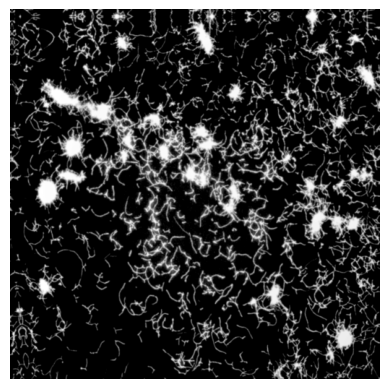

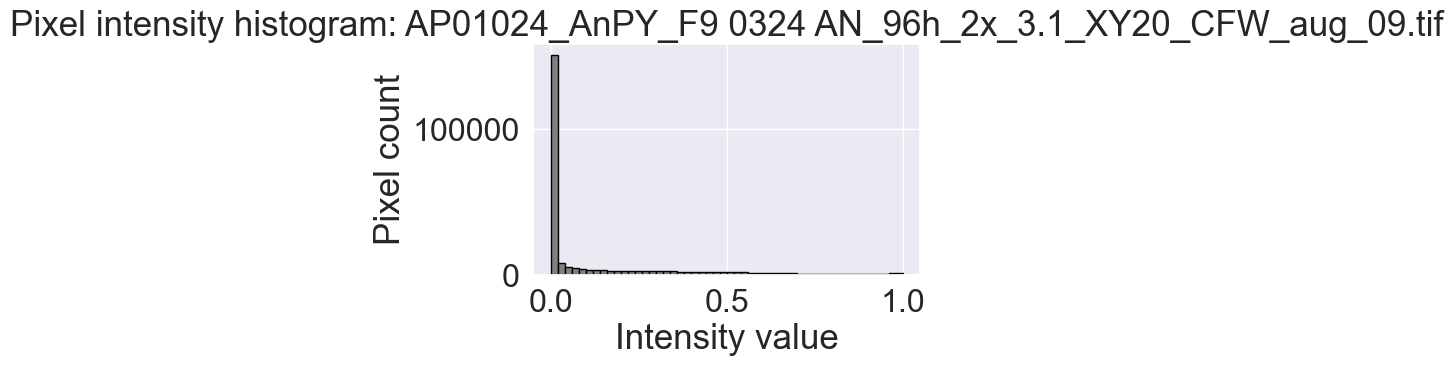


Image file: AP01024_AnPY_F9 0324 AN_96h_2x_3.1_XY20_CFW_aug_09.tif
--------------------------------------------------
psi_raw: 81.50887748320837
psi_norm: 0.15368454158306122
post_ind_time: 80.0
post_ind_time_norm: 0.36866360902786255
inoc: 0.0
overp: 0.0
stirr_val: 550.0
stirr_norm: 0.48245614767074585
medN: 0.0
medP: 0.0
visc: 1.3631805177736596
visc_norm: 0.27724865078926086
exp: AP01024
bio: F9 0324 AN


In [209]:
# pick random sample
idx = random.randint(0, len(dataset)-1)
filename = dataset.image_files[idx]
img, *info = dataset[idx]

# show the image with full [0,1] contrast range
plt.imshow(img.squeeze(), cmap="gray")
plt.axis("off")
plt.show()

# convert to numpy and flatten
values = img.squeeze().numpy().flatten()
# plot histogram
plt.figure(figsize=(5,3))
plt.hist(values, bins=50, color="gray", edgecolor="black")
plt.title(f"Pixel intensity histogram: {filename}")
plt.xlabel("Intensity value")
plt.ylabel("Pixel count")
plt.show()

# correct labels in right order
labels = [
    "psi_raw", "psi_norm", "post_ind_time", "post_ind_time_norm", "inoc", "overp", "stirr_val", "stirr_norm",
    "medN", "medP", "visc", "visc_norm", "exp", "bio"
]

print(f"\nImage file: {filename}\n" + "-"*50)
for name, val in zip(labels, info):
    print(f"{name}: {val}")


In [219]:
times       = np.array([dataset[i][3] for i in orig_indices])
inoculum    = np.array([dataset[i][5].item() for i in orig_indices])
overpress   = np.array([dataset[i][6].item() for i in orig_indices])
stirring    = np.array([dataset[i][7] for i in orig_indices])
medN        = np.array([dataset[i][8].item() for i in orig_indices])
medP        = np.array([dataset[i][9].item() for i in orig_indices])

n_bins = 5
post_time_bin = pd.qcut(times, q=n_bins, labels=False, duplicates='drop').astype(int)
stir_lvl = np.round(stirring, 0).astype(int)

df_strat = pd.DataFrame({
    'PostTimeBin': post_time_bin,
    'StirRateLvl': stir_lvl,
    'Inoculum': inoculum.astype(int),
    'Overpressure': overpress.astype(int),
    'Medium_N': medN.astype(int),
    'Medium_P': medP.astype(int),
})

strata = df_strat.astype(str).agg('_'.join, axis=1)

orig_train_idx, orig_test_idx = train_test_split(
    orig_indices,
    test_size=0.20,
    random_state=42,
    stratify=strata
)

train_strata = strata[[orig_indices.index(i) for i in orig_train_idx]]

orig_train_idx, orig_val_idx = train_test_split(
    orig_train_idx,
    test_size=0.125,   # 0.125 × 0.8 = 0.10
    random_state=42,
    stratify=train_strata
)

# Map: original filename → all augmented versions
aug_map = defaultdict(list)

for i in aug_indices:
    base = re.sub(r"_aug_\d+", "", dataset.image_files[i])
    aug_map[base].append(i)

# Build final training indices
final_train_indices = []

for i in orig_train_idx:
    final_train_indices.append(i)
    base = dataset.image_files[i]
    final_train_indices.extend(aug_map.get(base, []))

train_dataset = Subset(dataset, final_train_indices)
val_dataset   = Subset(dataset, orig_val_idx)
test_dataset  = Subset(dataset, orig_test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [220]:
print("Final split sizes:")
print(f"Train originals: {len(orig_train_idx)}")
print(f"Train augmented samples: {len(train_loader.dataset)}, batches: {len(train_loader)}")
print(f"Val samples:   {len(val_loader.dataset)}, batches: {len(val_loader)}")
print(f"Test samples:  {len(test_loader.dataset)}, batches: {len(test_loader)}")


Final split sizes:
Train originals: 376
Train augmented samples: 7896, batches: 247
Val samples:   54, batches: 2
Test samples:  108, batches: 4


In [221]:
class RegressionEfficientNet(nn.Module):
    def __init__(self):
        super(RegressionEfficientNet, self).__init__()

        # ---- EfficientNet backbone ----
        self.model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
        weight = self.model.features[0][0].weight
        new_weight = weight.mean(dim=1, keepdim=True)  # Convert to 1-channel input
        self.model.features[0][0] = nn.Conv2d(1, 40, kernel_size=3, stride=2, padding=1, bias=False)
        self.model.features[0][0].weight = nn.Parameter(new_weight)

        # Optionally freeze the EfficientNet backbone
        for param in self.model.features.parameters():
            param.requires_grad = False

        in_features = self.model.classifier[1].in_features

        # ---- Image feature branch ----
        self.image_fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU()
        )

        # ---- Fusion + Regression head ----
        # Combine 128-D image vector + 6 scalar features
        self.regressor = nn.Sequential(
            nn.Linear(128 + 6, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.ReLU()
        )

    def forward(self, x, meta):
        """
        meta: tensor of shape [batch, 6] containing:
              [time_norm, inoculum_enc, stirring_norm, overpressure_enc,
               medium_N, medium_P]
        """
        # --- Extract image features ---
        img_features = self.model.features(x)
        img_features = self.model.avgpool(img_features)
        img_features = torch.flatten(img_features, 1)
        img_embed = self.image_fc(img_features)

        # --- Concatenate image and experimental features ---
        fused = torch.cat([img_embed, meta], dim=1)

        # --- Predict psilocybin ---
        output = self.regressor(fused)
        return output


In [222]:
# Initialize Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RegressionEfficientNet().to(device)

# Loss Function & Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, weight_decay=1e-4)

# **Learning Rate Scheduler**
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)


In [223]:
# === Training Loop ===

save_dir = ".../../" #Specify the models save directory
os.makedirs(save_dir, exist_ok=True)

patience = 20
min_epochs = 100
best_val_r2 = 0.75
epochs_no_improve = 0

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=200):
    global best_val_r2, epochs_no_improve

    train_losses, val_losses = [], []
    train_mae_scores, val_mae_scores = [], []
    train_r2_scores, val_r2_scores = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        all_train_preds, all_train_targets = [], []

        # ---- TRAIN ----
        for batch in train_loader:
            (
                images, psilocybin, psi_norm, time, time_norm,
                inoc, overp, stirr, stirr_norm, medN, medP,
                visc, visc_norm, *_  # ignore exp/bio
            ) = batch

            images = images.to(device)
            psi_norm = psi_norm.to(device).unsqueeze(1)

            # build metadata tensor [B,6]
            meta = torch.cat([
                time_norm.unsqueeze(1),
                inoc.unsqueeze(1),
                stirr_norm.unsqueeze(1),
                overp.unsqueeze(1),
                medN.unsqueeze(1),
                medP.unsqueeze(1)
            ], dim=1).to(device)
            # visc_norm.unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(images, meta)
            loss = criterion(outputs, psi_norm)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            all_train_preds.extend(outputs.detach().cpu().numpy().flatten())
            all_train_targets.extend(psi_norm.cpu().numpy().flatten())

        max_psi = dataset.max_psilocybin  # <-- get your normalization constant
        
        # Denormalize predictions and targets
        all_train_preds_real = np.array(all_train_preds) * max_psi
        all_train_targets_real = np.array(all_train_targets) * max_psi

        avg_train_loss = running_loss / len(train_loader)
        train_mae = mean_absolute_error(all_train_targets_real, all_train_preds_real)
        train_r2 = r2_score(all_train_targets_real, all_train_preds_real)
        train_losses.append(avg_train_loss)
        train_mae_scores.append(train_mae)
        train_r2_scores.append(train_r2)

        # ---- VALIDATION ----
        model.eval()
        val_loss = 0.0
        all_val_preds, all_val_targets = [], []

        with torch.no_grad():
            for batch in val_loader:
                (
                    images, psilocybin, psi_norm, time, time_norm,
                    inoc, overp, stirr, stirr_norm, medN, medP,
                    visc, visc_norm, *_  
                ) = batch

                images = images.to(device)
                psi_norm = psi_norm.to(device).unsqueeze(1)

                meta = torch.cat([
                    time_norm.unsqueeze(1),
                    inoc.unsqueeze(1),
                    stirr_norm.unsqueeze(1),
                    overp.unsqueeze(1),
                    medN.unsqueeze(1),
                    medP.unsqueeze(1)
                ], dim=1).to(device)
                #visc_norm.unsqueeze(1)

                outputs = model(images, meta)
                loss = criterion(outputs, psi_norm)

                val_loss += loss.item()
                all_val_preds.extend(outputs.cpu().numpy().flatten())
                all_val_targets.extend(psi_norm.cpu().numpy().flatten())

        all_val_preds_real = np.array(all_val_preds) * max_psi
        all_val_targets_real = np.array(all_val_targets) * max_psi

        avg_val_loss = val_loss / len(val_loader)
        val_mae = mean_absolute_error(all_val_targets_real, all_val_preds_real)
        val_r2 = r2_score(all_val_targets_real, all_val_preds_real)
        val_losses.append(avg_val_loss)
        val_mae_scores.append(val_mae)
        val_r2_scores.append(val_r2)

        scheduler.step(avg_val_loss)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Train MAE: {train_mae:.4f} | Val MAE: {val_mae:.4f} | "
              f"Train R²: {train_r2:.4f} | Val R²: {val_r2:.4f}")

        # ---- Save & Early Stop ----
        if val_r2 > best_val_r2:
            best_val_r2 = val_r2
            epochs_no_improve = 0

            model_path = os.path.join(save_dir, f"best_model_epoch_{epoch+1}_valr2_{val_r2:.3f}.pth")
            torch.save(model.state_dict(), model_path)
            print(f"🔹 Saved best model → {model_path}")
        
            # **Save Training and Validation Results**
            training_results = {
                "train_losses": train_losses,
                "val_losses": val_losses,
                "train_mae_scores": train_mae_scores,
                "val_mae_scores": val_mae_scores,               
                "train_r2_scores": train_r2_scores,
                "val_r2_scores": val_r2_scores
            }

            results_filename = f"training_results_epoch_{epoch+1}_val_r2_{val_r2:.3f}.pkl"
            training_results_path = os.path.join(save_dir, results_filename)
            with open(training_results_path, "wb") as f:
                pickle.dump(training_results, f)
            print(f"✅ Training results saved successfully at: {training_results_path}")       
  
        else:
            epochs_no_improve += 1

        if epoch + 1 >= min_epochs and epochs_no_improve >= patience:
            print(f"🚨 Early stopping triggered after {epoch+1} epochs! No R² improvement for {patience} consecutive epochs.")

            model_path = os.path.join(save_dir, f"stop_model_epoch_{epoch+1}_valr2_{val_r2:.3f}.pth")
            torch.save(model.state_dict(), model_path)
            print(f"🔹 Saved last model → {model_path}")
        
            # **Save Training and Validation Results**
            training_results = {
                "train_losses": train_losses,
                "val_losses": val_losses,
                "train_mae_scores": train_mae_scores,
                "val_mae_scores": val_mae_scores,               
                "train_r2_scores": train_r2_scores,
                "val_r2_scores": val_r2_scores
            }

            results_filename = f"training_results_epoch_{epoch+1}_val_r2_{val_r2:.3f}.pkl"
            training_results_path = os.path.join(save_dir, results_filename)
            with open(training_results_path, "wb") as f:
                pickle.dump(training_results, f)
            print(f"✅ Training results saved successfully at: {training_results_path}")             
              
            break

    return train_losses, val_losses, train_mae_scores, val_mae_scores, train_r2_scores, val_r2_scores


# === Train ===
train_losses, val_losses, train_mae_scores, val_mae_scores, train_r2_scores, val_r2_scores = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=200
)


Epoch 1/200 | Train Loss: 0.0252 | Val Loss: 0.0220 | Train MAE: 60.3655 | Val MAE: 53.4148 | Train R²: 0.6028 | Val R²: 0.6748
Epoch 2/200 | Train Loss: 0.0138 | Val Loss: 0.0153 | Train MAE: 44.5826 | Val MAE: 44.9272 | Train R²: 0.7833 | Val R²: 0.7662
🔹 Saved best model → D:/Sophie/Deep learning prediction of production/New try Jan. 2026/Bioreactor/Cropped2 CLAHE 512 M2 Augmented/best_model_epoch_2_valr2_0.766.pth
✅ Training results saved successfully at: D:/Sophie/Deep learning prediction of production/New try Jan. 2026/Bioreactor/Cropped2 CLAHE 512 M2 Augmented/training_results_epoch_2_val_r2_0.766.pkl
Epoch 3/200 | Train Loss: 0.0108 | Val Loss: 0.0094 | Train MAE: 39.3411 | Val MAE: 36.0378 | Train R²: 0.8304 | Val R²: 0.8550
🔹 Saved best model → D:/Sophie/Deep learning prediction of production/New try Jan. 2026/Bioreactor/Cropped2 CLAHE 512 M2 Augmented/best_model_epoch_3_valr2_0.855.pth
✅ Training results saved successfully at: D:/Sophie/Deep learning prediction of production

Test Loss: 0.0121
R² Score:  0.8724
MAE:       30.9257


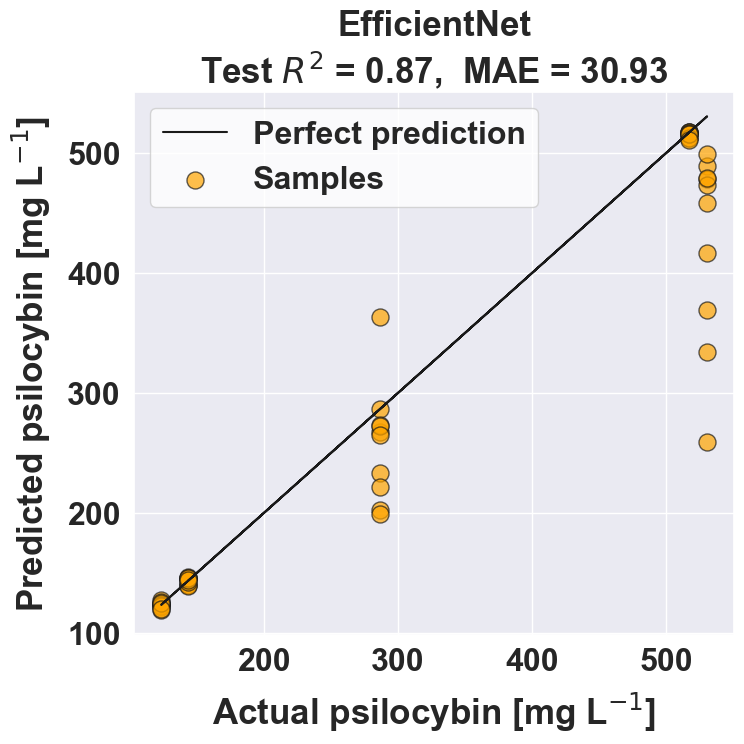

In [250]:
# Test
model_path = ".../best_model.pth" #Specify the .pth model path

# Load architecture and weights
model = RegressionEfficientNet().to(device)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.eval()

test_loss = 0.0
predictions, true_labels = [], []

with torch.no_grad():
    for (
        images, psilocybin, psi_norm, time, time_norm,
        inoc, overp, stirr, stirr_norm, medN, medP,
        visc, visc_norm, *_  # ignore exp/bio
    ) in test_loader:

        images = images.to(device)
        psi_norm = psi_norm.to(device).unsqueeze(1)

        # Construct metadata tensor [B,7]
        meta = torch.cat([
            time_norm.unsqueeze(1),
            inoc.unsqueeze(1),
            stirr_norm.unsqueeze(1),
            overp.unsqueeze(1),
            medN.unsqueeze(1),
            medP.unsqueeze(1)
        ], dim=1).to(device)

        outputs = model(images, meta)
        loss = criterion(outputs, psi_norm)
        test_loss += loss.item()

        # Denormalize predictions and true labels
        max_psi = dataset.max_psilocybin
        predictions.extend((outputs.cpu().numpy().flatten() * max_psi).tolist())
        true_labels.extend((psi_norm.cpu().numpy().flatten() * max_psi).tolist())

# ---- Compute Metrics ----
mean_test_loss = test_loss / len(test_loader)
r2 = r2_score(true_labels, predictions)
mae = mean_absolute_error(true_labels, predictions)

print(f"Test Loss: {mean_test_loss:.4f}")
print(f"R² Score:  {r2:.4f}")
print(f"MAE:       {mae:.4f}")

# ---- Visualization ----
sns.set(style="darkgrid", font_scale=2.1)
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(true_labels, true_labels, color='k', label='Perfect prediction')
ax.scatter(true_labels, predictions, edgecolor='k', facecolor='orange',
           s=150, alpha=0.7, label='Samples')

ax.set_xlabel(r"Actual psilocybin [mg L$^{-1}$]", labelpad=10)
ax.set_ylabel(r"Predicted psilocybin [mg L$^{-1}$]", labelpad=10)
ax.legend(facecolor='white')
ax.set_title(f'EfficientNet\nTest $R^2$ = {r2:.2f},  MAE = {mae:.2f}')

fig.tight_layout()
plt.show()


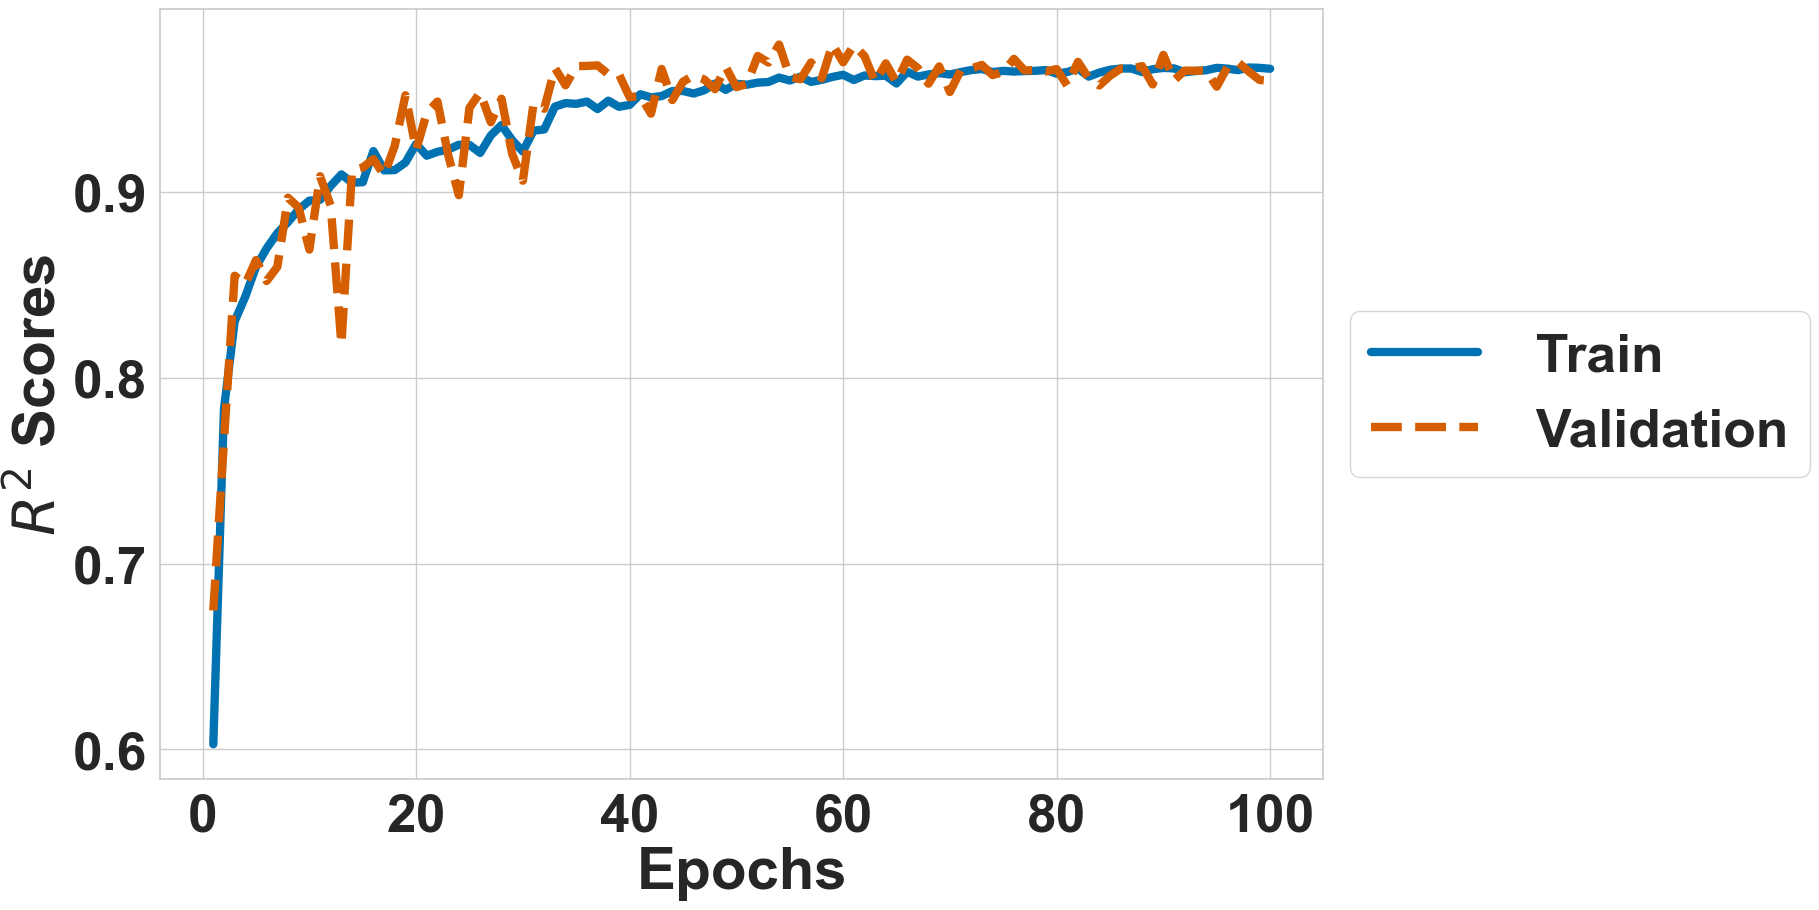

In [246]:
# Provide the paths to your .pkl files
pkl_files = {
    "": ".../training_results.pkl",
}

# Dictionary to store train and validation losses
train_r2_dict = {}
val_r2_dict = {}

# Load train_losses and val_losses from each file
for model_name, file_path in pkl_files.items():
    with open(file_path, "rb") as f:
        training_results = pickle.load(f)
        train_r2_dict[model_name] = training_results["train_r2_scores"]
        val_r2_dict[model_name] = training_results["val_r2_scores"]

# Create the plot
plt.figure(figsize=(15, 10))
sns.set(style="whitegrid", font_scale = 3.5)

# Generate a color palette for consistency
palette = sns.color_palette("tab10", len(pkl_files))  # Generate distinct colors for each model

# Plot train and validation losses
for (model_name, train_r2), val_r2, color in zip(train_r2_dict.items(), val_r2_dict.values(), palette):
    # Plot train loss (solid line)
    sns.lineplot(x=range(1, 101), y=train_r2[0:100], label=f"{model_name} Train", linestyle="-", lw=6, color='#0072B2')

    # Plot validation loss (dashed line, same color)
    sns.lineplot(x=range(1, 101), y=val_r2[0:100], label=f"{model_name} Validation", linestyle="--", lw=6, color='#D55E00')

# Customize the plot
plt.xlabel("Epochs")
plt.ylabel("$R^2$ Scores")
#plt.ylim([0.6, 1])
#plt.title("Validation $R^2$ Scores", pad=15)

# Move legend to the right
plt.legend(title="", loc="center left", bbox_to_anchor=(1, 0.5))
plt.grid(True)

# Show the plot
plt.show()


In [215]:
# Leave-one-out-cross-validatoin (LOOCV)

# === Early stopping parameters ===
patience = 20
min_epochs = 100
best_val_r2 = 0.70
epochs_no_improve = 0

# === Extract bioreactor labels ===
bioreactors = np.array([dataset[i][14] for i in range(len(dataset))])  # Bioreactor name
unique_bioreactors = sorted(np.unique(bioreactors))

# === LOBO main loop ===
for test_bioreactor in unique_bioreactors:
    print(f"\n=== Training Excluding Bioreactor: {test_bioreactor} ===")

    # --- Create save directory ---
    save_dir = os.path.join(
        ".../../", #specify the save directory
        test_bioreactor
    )
    os.makedirs(save_dir, exist_ok=True)

    # --- Split train/test by bioreactor (NO AUGMENTATION LEAKAGE) ---
    all_files = dataset.image_files
    
    # --- Separate original & augmented indices ---
    orig_indices = [i for i, f in enumerate(all_files) if not is_augmented(f)]
    aug_indices  = [i for i, f in enumerate(all_files) if is_augmented(f)]
    
    # --- Identify original test samples (held-out bioreactor) ---
    orig_test_indices = [
        i for i in orig_indices
        if dataset[i][14] == test_bioreactor
    ]
    
    # --- Remaining original samples for train/val ---
    orig_trainval_indices = [
        i for i in orig_indices
        if dataset[i][14] != test_bioreactor
    ]
    
    # --- STRATIFICATION FEATURES (ORIGINALS ONLY) ---
    times       = np.array([dataset[i][3] for i in orig_trainval_indices])
    inoculum    = np.array([dataset[i][5].item() for i in orig_trainval_indices])
    overpress   = np.array([dataset[i][6].item() for i in orig_trainval_indices])
    stirring    = np.array([dataset[i][7] for i in orig_trainval_indices])
    medN        = np.array([dataset[i][8].item() for i in orig_trainval_indices])
    medP        = np.array([dataset[i][9].item() for i in orig_trainval_indices])
    
    n_bins = 5
    post_time_bin = pd.qcut(times, q=n_bins, labels=False, duplicates='drop').astype(int)
    stir_lvl = np.round(stirring, 0).astype(int)
    
    df_strat = pd.DataFrame({
        'PostTimeBin': post_time_bin,
        'StirRateLvl': stir_lvl,
        'Inoculum': inoculum.astype(int),
        'Overpressure': overpress.astype(int),
        'Medium_N': medN.astype(int),
        'Medium_P': medP.astype(int),
    })
    
    strata = df_strat.astype(str).agg('_'.join, axis=1)

    # --- TRAIN / VAL SPLIT (ORIGINALS ONLY) ---
    orig_train_indices, orig_val_indices = train_test_split(
        orig_trainval_indices,
        test_size=0.10,
        random_state=42,
        stratify=strata
    )
    
    # --- MAP AUGMENTATIONS TO TRAINING ONLY ---  
    aug_map = defaultdict(list)
    
    for i in aug_indices:
        base = re.sub(r"_aug_\d+", "", dataset.image_files[i])
        aug_map[base].append(i)
    
    final_train_indices = []
    
    for i in orig_train_indices:
        final_train_indices.append(i)
        base = dataset.image_files[i]
        final_train_indices.extend(aug_map.get(base, []))
    
    # ==========================================================
    # === SANITY CHECKS (NO LEAKAGE) ===========================
    # ========================================================== 
    print(f"\n[{test_bioreactor}] Split summary:")
    print(f"  Train originals: {len(orig_train_indices)}")
    print(f"  Train total (with augmentation): {len(final_train_indices)}")
    print(f"  Validation (originals only): {len(orig_val_indices)}")
    print(f"  Test (originals only): {len(orig_test_indices)}")
    
    # --- Assert no augmented samples in val/test ---
    assert all("_aug_" not in dataset.image_files[i] for i in orig_val_indices), \
        "❌ Augmented image found in validation set!"
    
    assert all("_aug_" not in dataset.image_files[i] for i in orig_test_indices), \
        "❌ Augmented image found in test set!"
    
    # --- Create subsets --- 
    train_dataset = Subset(dataset, final_train_indices)
    val_dataset   = Subset(dataset, orig_val_indices)
    test_dataset  = Subset(dataset, orig_test_indices)

    # --- Weighted sampler (Training only, with augmentation) ---
    exp_time_counts = Counter([(dataset[i][14], dataset[i][3]) for i in final_train_indices])
    weights = np.array([1.0 / exp_time_counts[(dataset[i][14], dataset[i][3])] for i in final_train_indices])
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

    # --- Dataloaders ---
    train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
    val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # === Initialize model and optimizer ===
    model = RegressionEfficientNet().to(device)
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_val_r2 = 0.70
    epochs_no_improve = 0

    # --- Metric trackers ---
    train_losses, val_losses = [], []
    train_mae_scores, val_mae_scores = [], []
    train_r2_scores, val_r2_scores = [], []

    # === TRAINING LOOP ===
    for epoch in range(200):
        model.train()
        running_loss = 0.0
        all_train_preds, all_train_targets = [], []

        for batch in train_loader:
            (
                images, psilocybin, psi_norm, time, time_norm,
                inoc, overp, stirr, stirr_norm, medN, medP,
                visc, visc_norm, *_  
            ) = batch

            images = images.to(device)
            psi_norm = psi_norm.to(device).unsqueeze(1)

            # build metadata tensor [B,6]
            meta = torch.cat([
                time_norm.unsqueeze(1),
                inoc.unsqueeze(1),
                stirr_norm.unsqueeze(1),
                overp.unsqueeze(1),
                medN.unsqueeze(1),
                medP.unsqueeze(1)
            ], dim=1).to(device)

            optimizer.zero_grad()
            outputs = model(images, meta)
            loss = criterion(outputs, psi_norm)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            all_train_preds.extend(outputs.detach().cpu().numpy().flatten())
            all_train_targets.extend(psi_norm.cpu().numpy().flatten())

        # --- Denormalize for metrics ---
        max_psi = dataset.max_psilocybin
        all_train_preds_real = np.array(all_train_preds) * max_psi
        all_train_targets_real = np.array(all_train_targets) * max_psi

        avg_train_loss = running_loss / len(train_loader)
        train_mae = mean_absolute_error(all_train_targets_real, all_train_preds_real)
        train_r2 = r2_score(all_train_targets_real, all_train_preds_real)
        train_losses.append(avg_train_loss)
        train_mae_scores.append(train_mae)
        train_r2_scores.append(train_r2)

        # === VALIDATION ===
        model.eval()
        val_loss = 0.0
        all_val_preds, all_val_targets = [], []

        with torch.no_grad():
            for batch in val_loader:
                (
                    images, psilocybin, psi_norm, time, time_norm,
                    inoc, overp, stirr, stirr_norm, medN, medP,
                    visc, visc_norm, *_  
                ) = batch

                images = images.to(device)
                psi_norm = psi_norm.to(device).unsqueeze(1)

                meta = torch.cat([
                    time_norm.unsqueeze(1),
                    inoc.unsqueeze(1),
                    stirr_norm.unsqueeze(1),
                    overp.unsqueeze(1),
                    medN.unsqueeze(1),
                    medP.unsqueeze(1)
                ], dim=1).to(device)

                outputs = model(images, meta)
                loss = criterion(outputs, psi_norm)
                val_loss += loss.item()

                all_val_preds.extend(outputs.cpu().numpy().flatten())
                all_val_targets.extend(psi_norm.cpu().numpy().flatten())

        all_val_preds_real = np.array(all_val_preds) * max_psi
        all_val_targets_real = np.array(all_val_targets) * max_psi

        avg_val_loss = val_loss / len(val_loader)
        val_mae = mean_absolute_error(all_val_targets_real, all_val_preds_real)
        val_r2 = r2_score(all_val_targets_real, all_val_preds_real)
        val_losses.append(avg_val_loss)
        val_mae_scores.append(val_mae)
        val_r2_scores.append(val_r2)

        scheduler.step(avg_val_loss)

        print(f"[{test_bioreactor}] Epoch {epoch+1:03d} | "
              f"Train Loss={avg_train_loss:.4f} | Val Loss={avg_val_loss:.4f} | "
              f"Train MAE={train_mae:.3f} | Val MAE={val_mae:.3f} | "
              f"Train R²={train_r2:.3f} | Val R²={val_r2:.3f}")

        # === Save best model ===
        if val_r2 > best_val_r2:
            best_val_r2 = val_r2
            epochs_no_improve = 0

            model_path = os.path.join(save_dir, f"best_model_epoch_{epoch+1}_valr2_{val_r2:.3f}.pth")
            torch.save(model.state_dict(), model_path)
            print(f"🔹 Best model saved → {model_path}")

            results = {
                "train_losses": train_losses,
                "val_losses": val_losses,
                "train_mae_scores": train_mae_scores,
                "val_mae_scores": val_mae_scores,
                "train_r2_scores": train_r2_scores,
                "val_r2_scores": val_r2_scores
            }
            with open(os.path.join(save_dir, f"training_results_epoch_{epoch+1}_valr2_{val_r2:.3f}.pkl"), "wb") as f:
                pickle.dump(results, f)
        else:
            epochs_no_improve += 1

        # === Early stopping ===
        if epoch + 1 >= min_epochs and epochs_no_improve >= patience:
            print(f"⛔ Early stopping at epoch {epoch+1} for {test_bioreactor}")
   
            # ✅ Save last model and results before stopping
            model_path = os.path.join(save_dir, f"stop_model_epoch_{epoch+1}_valr2_{val_r2:.3f}.pth")
            torch.save(model.state_dict(), model_path)
            print(f"💾 Model saved at early stop → {model_path}")
    
            results = {
                "train_losses": train_losses,
                "val_losses": val_losses,
                "train_mae_scores": train_mae_scores,
                "val_mae_scores": val_mae_scores,
                "train_r2_scores": train_r2_scores,
                "val_r2_scores": val_r2_scores
            }
            results_path = os.path.join(save_dir, f"training_results_epoch_{epoch+1}_valr2_{val_r2:.3f}.pkl")
            with open(results_path, "wb") as f:
                pickle.dump(results, f)
            print(f"📁 Early-stopped results saved → {results_path}")
     
            break



=== Training Excluding Bioreactor: F3 0125 AN ===

[F3 0125 AN] Split summary:
  Train originals: 421
  Train total (with augmentation): 8841
  Validation (originals only): 47
  Test (originals only): 70
[F3 0125 AN] Epoch 001 | Train Loss=0.0330 | Val Loss=0.0220 | Train MAE=67.908 | Val MAE=53.903 | Train R²=0.460 | Val R²=0.623
[F3 0125 AN] Epoch 002 | Train Loss=0.0153 | Val Loss=0.0094 | Train MAE=47.086 | Val MAE=35.679 | Train R²=0.751 | Val R²=0.856
🔹 Best model saved → D:/Sophie/Deep learning prediction of production/New try Jan. 2026/Bioreactor/LOBO M2 Augmented/F3 0125 AN\best_model_epoch_2_valr2_0.856.pth
[F3 0125 AN] Epoch 003 | Train Loss=0.0121 | Val Loss=0.0081 | Train MAE=41.826 | Val MAE=35.042 | Train R²=0.802 | Val R²=0.872
🔹 Best model saved → D:/Sophie/Deep learning prediction of production/New try Jan. 2026/Bioreactor/LOBO M2 Augmented/F3 0125 AN\best_model_epoch_3_valr2_0.872.pth
[F3 0125 AN] Epoch 004 | Train Loss=0.0105 | Val Loss=0.0048 | Train MAE=38.513 | 